# Berka Dataset Exploratory Data Analysis

Este notebook implementa uma EDA completa para cada uma das 5 tabelas que compoem a camada `silver/` (`district`, `client`,
`account`, `order`, `trans`), com o objetivo de abordar os seguintes aspectos:
 - Dicionário de dados
 - Volume, tipo e formato
 - Indicadores e chaves primárias/estrangeiras
 - Nulos, duplicatas e valores fora do padrão
 - Gráficos
 - Insights para a modelagem Gold*

Insights para a modelagem da Gold*: A camada gold será utilizada para alimentar um modelo de previsão de entradas mensais por conta.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path

%matplotlib inline
pd.set_option("display.max_columns", 30)

PROJECT_ROOT = Path.cwd().parent
SILVER_DIR = PROJECT_ROOT / "datalake" / "silver"

TABLES = ["district", "client", "account", "order", "trans"]
silver = {t: pd.read_parquet(SILVER_DIR / f"{t}.parquet") for t in TABLES}

for t in TABLES:
    print(f"{t:10s} shape={silver[t].shape}")


district   shape=(77, 16)
client     shape=(5369, 9)
account    shape=(4500, 10)
order      shape=(6471, 6)
trans      shape=(1056320, 10)


In [ ]:
# Paleta categórica
CATEGORICAL = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = CATEGORICAL

# Cmpas sequenciais e divergentes
SEQ_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "blue_seq", ["#cde2fb", "#6da7ec", "#2a78d6", "#184f95", "#0d366b"]
)
DIV_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "blue_red_div", ["#e34948", "#f0efec", "#2a78d6"]
)

INK, MUTED, GRID = "#0b0b0b", "#52514e", "#e1e0d9"

sns.set_theme(style="white", rc={
    "figure.facecolor": "#fcfcfb",
    "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c3c2b7",
    "axes.labelcolor": INK,
    "text.color": INK,
    "xtick.color": MUTED,
    "ytick.color": MUTED,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.7,
    "font.size": 10.5,
})


def finish(ax, title, xlabel="", ylabel=""):
    """Título/labels consistentes + despine, aplicado a todo gráfico."""
    ax.set_title(title, fontsize=12.5, fontweight="bold", color=INK, pad=10)
    ax.set_xlabel(xlabel, color=MUTED, fontsize=10)
    ax.set_ylabel(ylabel, color=MUTED, fontsize=10)
    sns.despine(ax=ax)
    return ax


In [3]:
def quality_overview(df: pd.DataFrame) -> pd.DataFrame:
    """Resumo de tipo, nulos e cardinalidade por coluna."""
    return pd.DataFrame({
        "dtype": df.dtypes.astype(str),
        "n_nulos": df.isna().sum(),
        "pct_nulos": (df.isna().mean() * 100).round(2),
        "n_unicos": df.nunique(),
        "pct_unicos": (df.nunique() / len(df) * 100).round(2),
    })


def outlier_iqr(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Outliers pela regra 1.5xIQR, coluna a coluna (só numéricas)."""
    rows = []
    for col in cols:
        s = df[col].dropna()
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = int(((s < low) | (s > high)).sum())
        rows.append({
            "coluna": col, "limite_inferior": round(low, 2), "limite_superior": round(high, 2),
            "n_outliers": n_out, "pct_outliers": round(n_out / len(s) * 100, 2),
        })
    return pd.DataFrame(rows).set_index("coluna")


def desconhecido_rate(df: pd.DataFrame, cols: list[str]) -> pd.DataFrame:
    """Taxa do marcador 'DESCONHECIDO' (nulo estrutural preenchido na Silver) por coluna."""
    rows = []
    for col in cols:
        n = int((df[col] == "DESCONHECIDO").sum())
        rows.append({"coluna": col, "n_desconhecido": n, "pct_desconhecido": round(n / len(df) * 100, 2)})
    return pd.DataFrame(rows).set_index("coluna")


def duplicate_report(df: pd.DataFrame, subset: list[str] | None = None) -> None:
    n_full = int(df.duplicated().sum())
    print(f"Linhas 100% duplicadas: {n_full}")
    if subset:
        n_sub = int(df.duplicated(subset=subset).sum())
        print(f"Linhas duplicadas em {subset}: {n_sub}")


# 1. `district`

## 1.1 Dicionário de dados

Esta tabela agrupa dados de natureza socioeconômica por distrito.\
Nota: O conjunto original as colunas possuem nomes como A1..A16, contudo foram renomeadas durante a ingestão na camada Silver.

| Coluna | Descrição |
|---|---|
| `district_id` (PK) | Chave de identificação do distrito (A1) |
| `district_name` | Nome do distrito (A2) |
| `region` | Região (A3) |
| `population` | Nº de habitantes (A4) |
| `municipalities_under_499` | Nº de municípios com menos de 499 habitantes (A5) |
| `municipalities_500_1999` | Nº de municípios com 500 a 1999 habitantes (A6) |
| `municipalities_2000_9999` | Nº de municípios com 2000 a 9999 habitantes (A7) |
| `municipalities_over_10000` | Nº de municípios com mais de 10000 habitantes (A8) |
| `cities` | Nº de cidades (A9) |
| `urban_population_ratio` | Proporção de habitantes urbanos (A10) |
| `average_salary` | Salário médio (A11) |
| `unemployment_rate_1995` | Taxa de desemprego em 1995 (A12) |
| `unemployment_rate_1996` | Taxa de desemprego em 1996 (A13) |
| `entrepreneurs_per_1000` | Nº de empreendedores por 1000 habitantes (A14) |
| `crimes_1995` | Nº de crimes cometidos em 1995 (A15) |
| `crimes_1996` | Nº de crimes cometidos em 1996 (A16) |



## 1.2 Volume, tipo e formato


In [4]:
district = silver["district"]
print(f"shape: {district.shape}")
district.dtypes


shape: (77, 16)


district_id                  string[python]
district_name                string[python]
region                       string[python]
population                            Int64
municipalities_under_499              Int64
municipalities_500_1999               Int64
municipalities_2000_9999              Int64
municipalities_over_10000             Int64
cities                                Int64
urban_population_ratio              float64
average_salary                        Int64
unemployment_rate_1995              float64
unemployment_rate_1996              float64
entrepreneurs_per_1000                Int64
crimes_1995                           Int64
crimes_1996                           Int64
dtype: object

In [5]:
district.describe().T


,count,mean,std,min,25%,50%,75%,max
population,77.0,133884.896104,136913.464909,42821.0,85852.0,108871.0,139012.0,1204953.0
municipalities_under_499,77.0,48.623377,32.741829,0.0,22.0,49.0,71.0,151.0
municipalities_500_1999,77.0,24.324675,12.780991,0.0,16.0,25.0,32.0,70.0
municipalities_2000_9999,77.0,6.272727,4.015222,0.0,4.0,6.0,8.0,20.0
municipalities_over_10000,77.0,1.727273,1.008338,0.0,1.0,2.0,2.0,5.0
cities,77.0,6.25974,2.435497,1.0,5.0,6.0,8.0,11.0
urban_population_ratio,77.0,63.035065,16.221727,33.9,51.9,59.8,73.5,100.0
average_salary,77.0,9031.675325,790.202347,8110.0,8512.0,8814.0,9317.0,12541.0
unemployment_rate_1995,77.0,3.115519,1.654914,0.29,1.79,2.825,3.85,7.34
unemployment_rate_1996,77.0,3.787013,1.90848,0.43,2.31,3.6,4.79,9.4


## 1.3 Indicadores e chaves primárias

In [6]:
print("district_id é PK (única e sem nulos)?", district['district_id'].is_unique and district['district_id'].notna().all())
print(f"Regiões distintas: {district['region'].nunique()} -> {sorted(district['region'].unique())}")
print(f"Distrito mais populoso: {district.loc[district['population'].idxmax(), 'district_name']} ({district['population'].max():,} hab.)")
print(f"Salário médio (entre distritos): {district['average_salary'].mean():.0f} (min {district['average_salary'].min()}, max {district['average_salary'].max()})")


district_id é PK (única e sem nulos)? True
Regiões distintas: 8 -> ['Prague', 'central Bohemia', 'east Bohemia', 'north Bohemia', 'north Moravia', 'south Bohemia', 'south Moravia', 'west Bohemia']
Distrito mais populoso: Hl.m. Praha (1,204,953 hab.)
Salário médio (entre distritos): 9032 (min 8110, max 12541)


## 1.4 Nulos, duplicatas e valores fora do padrão

In [7]:
quality_overview(district)


,dtype,n_nulos,pct_nulos,n_unicos,pct_unicos
district_id,string,0,0.0,77,100.00
district_name,string,0,0.0,77,100.00
region,string,0,0.0,8,10.39
population,Int64,0,0.0,77,100.00
municipalities_under_499,Int64,0,0.0,53,68.83
municipalities_500_1999,Int64,0,0.0,36,46.75
municipalities_2000_9999,Int64,0,0.0,17,22.08
municipalities_over_10000,Int64,0,0.0,6,7.79
cities,Int64,0,0.0,11,14.29
urban_population_ratio,float64,0,0.0,70,90.91


In [8]:
duplicate_report(district, subset=["district_id"])


Linhas 100% duplicadas: 0
Linhas duplicadas em ['district_id']: 0


In [9]:
numeric_cols = district.select_dtypes(include="number").columns.tolist()
outlier_iqr(district, numeric_cols)


,limite_inferior,limite_superior,n_outliers,pct_outliers
coluna,,,,
population,6112.00,218752.00,6,7.79
municipalities_under_499,-51.50,144.50,1,1.30
municipalities_500_1999,-8.00,56.00,1,1.30
municipalities_2000_9999,-2.00,14.00,3,3.90
municipalities_over_10000,-0.50,3.50,4,5.19
cities,0.50,12.50,0,0.00
urban_population_ratio,19.50,105.90,0,0.00
average_salary,7304.50,10524.50,4,5.19
unemployment_rate_1995,-1.30,6.94,2,2.60


## 1.5 Gráficos

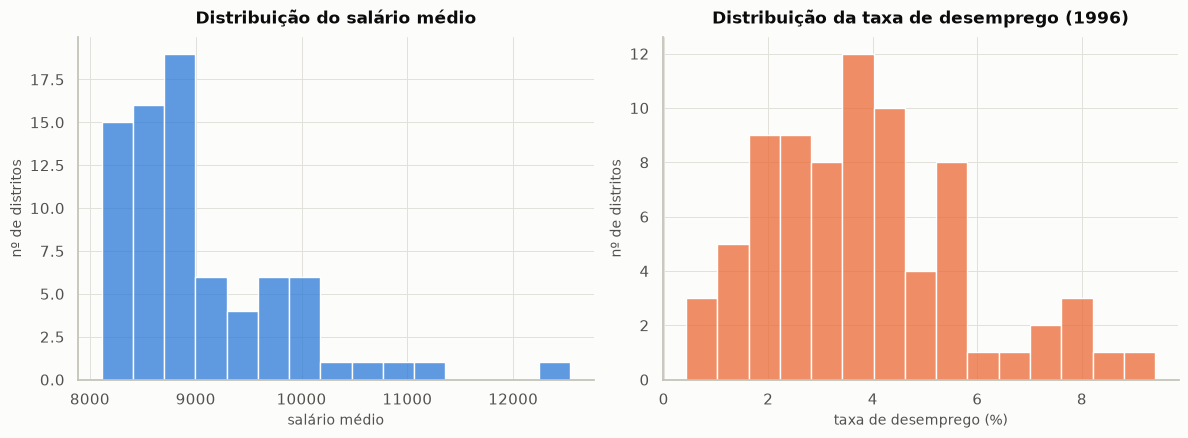

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(district["average_salary"], bins=15, color=BLUE, ax=axes[0])
finish(axes[0], "Distribuição do salário médio", "salário médio", "nº de distritos")

sns.histplot(district["unemployment_rate_1996"], bins=15, color=ORANGE, ax=axes[1])
finish(axes[1], "Distribuição da taxa de desemprego (1996)", "taxa de desemprego (%)", "nº de distritos")

plt.tight_layout()
plt.show()


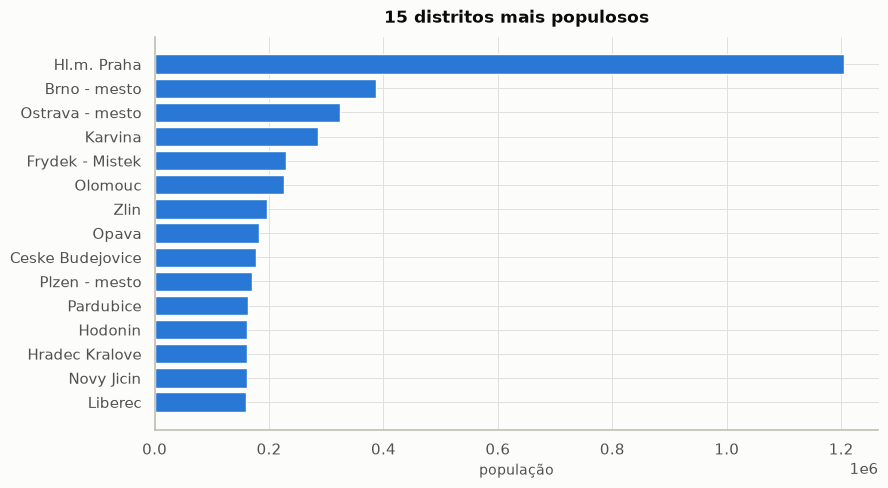

In [11]:
top = district.nlargest(15, "population").sort_values("population")

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top["district_name"], top["population"], color=BLUE)
finish(ax, "15 distritos mais populosos", "população", "")
plt.tight_layout()
plt.show()


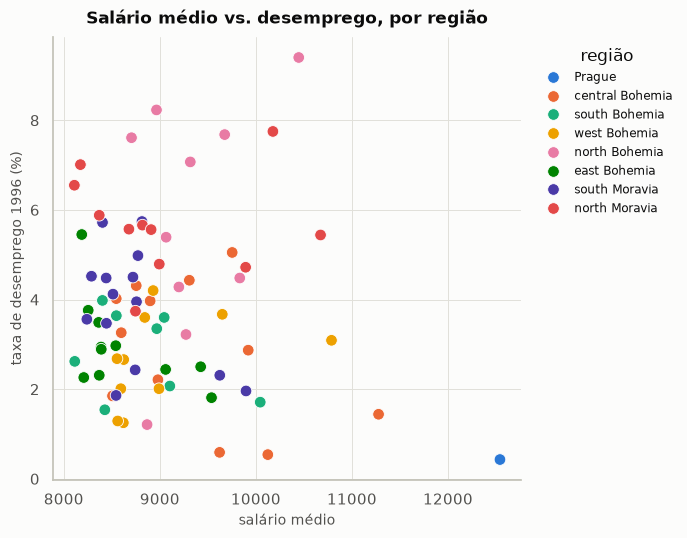

In [12]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sns.scatterplot(
    data=district, x="average_salary", y="unemployment_rate_1996",
    hue="region", palette=CATEGORICAL[: district["region"].nunique()],
    s=70, edgecolor="white", linewidth=0.6, ax=ax,
)
finish(ax, "Salário médio vs. desemprego, por região", "salário médio", "taxa de desemprego 1996 (%)")
ax.legend(title="região", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()


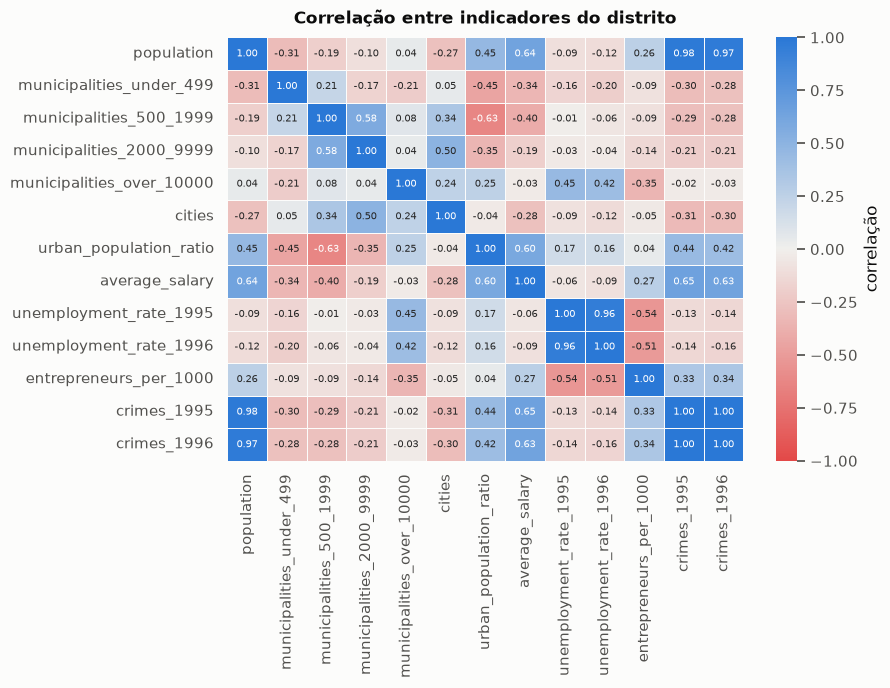

In [13]:
corr = district[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(
    corr, cmap=DIV_CMAP, center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
    annot_kws={"fontsize": 7.5}, linewidths=0.5, linecolor="#fcfcfb",
    cbar_kws={"label": "correlação"}, ax=ax,
)
ax.set_title("Correlação entre indicadores do distrito", fontsize=12.5, fontweight="bold", color=INK, pad=10)
plt.tight_layout()
plt.show()


## 1.6 Insights para a Gold

Visão Geral:\
Todas as 4500 contas estão distribruidas de maneira extremamente desigual por 77 distritos.\
A tabela armazena informações úteis que podem adicionar uma visão socioeconômica ao modelo.\
Atenção para:
- `average_salary`/`unemployment_rate_*`/`crimes_*` são as features distritais altamente correlacionadas e portanto redundantes, faz sentido manter todas na gold?
- `population` está fortemente concentrada num único distrito (Praga). Normalizar ou descartar essa feature na etapa de modelagem?

# 2. `client`

## 2.1 Dicionário de dados

Esta tabela reune os dados e as relações entre as entidades cliente, conta e cartão.\
Nota: A tabela nasce é fruto da consolidação das tabelas `client` + `disp` + `card` do schema original.

| Coluna | Descrição |
|---|---|
| `client_id` (PK) | Chave de identificação do cliente |
| `account_id` (FK -> `account`) | Conta do cliente (todo cliente pertence a exatamente 1 conta) |
| `relationship_type` | Papel na conta: `TITULAR` (único que pode emitir ordens/empréstimos) ou `DEPENDENTE` |
| `district_id` (FK -> `district`) | Distrito de residência |
| `gender` | Sexo (`M`/`F`), derivado de `birth_number` |
| `birth_date` | Data de nascimento, derivada de `birth_number` |
| `card_id` | Chave do cartão (nulo se sem cartão — só titular pode ter) |
| `card_type` | Tipo de cartão: `junior`, `classic`, `gold` (nulo se sem cartão) |
| `card_issued` | Data de emissão do cartão (nulo se sem cartão) |


## 2.2 Volume, tipo e formato

In [14]:
client = silver["client"]
print(f"shape: {client.shape}")
client.dtypes


shape: (5369, 9)


client_id            string[python]
account_id           string[python]
relationship_type    string[python]
district_id          string[python]
gender               string[python]
birth_date           datetime64[ns]
card_id              string[python]
card_type            string[python]
card_issued          datetime64[ns]
dtype: object

## 2.3 Indicadores e chaves primárias

In [15]:
print("client_id é PK (única e sem nulos)?", client['client_id'].is_unique and client['client_id'].notna().all())
print("account_id -> account.account_id (FK íntegra)?", client['account_id'].isin(silver['account']['account_id']).all())
print("district_id -> district.district_id (FK íntegra)?", client['district_id'].isin(silver['district']['district_id']).all())

per_acc = client.groupby("account_id")["relationship_type"].value_counts().unstack(fill_value=0)
print("max titulares/conta:", per_acc.get("TITULAR", pd.Series(dtype=int)).max(),
      "| max dependentes/conta:", per_acc.get("DEPENDENTE", pd.Series(dtype=int)).max())

titular = client[client["relationship_type"] == "TITULAR"]
print(f"taxa titular c/ cartão: {titular['card_type'].notna().mean():.2%}")
dep_rate = per_acc.get("DEPENDENTE", 0).gt(0).mean()
print(f"taxa conta c/ dependente: {dep_rate:.2%}")


client_id é PK (única e sem nulos)? True
account_id -> account.account_id (FK íntegra)? True
district_id -> district.district_id (FK íntegra)? True
max titulares/conta: 1 | max dependentes/conta: 1
taxa titular c/ cartão: 19.82%
taxa conta c/ dependente: 19.31%


## 2.4 Nulos, duplicatas e valores fora do padrão

In [16]:
quality_overview(client)


,dtype,n_nulos,pct_nulos,n_unicos,pct_unicos
client_id,string,0,0.00,5369,100.00
account_id,string,0,0.00,4500,83.81
relationship_type,string,0,0.00,2,0.04
district_id,string,0,0.00,77,1.43
gender,string,0,0.00,2,0.04
birth_date,datetime64[ns],0,0.00,4738,88.25
card_id,string,4477,83.39,892,16.61
card_type,string,4477,83.39,3,0.06
card_issued,datetime64[ns],4477,83.39,607,11.31


In [17]:
duplicate_report(client, subset=["client_id"])
print("\n(nulos em card_id/card_type/card_issued são estruturais: só titular pode ter cartão, e a maioria não tem)")


Linhas 100% duplicadas: 0
Linhas duplicadas em ['client_id']: 0

(nulos em card_id/card_type/card_issued são estruturais: só titular pode ter cartão, e a maioria não tem)


In [18]:
ref_date = pd.Timestamp("1998-12-31")
age_years = (ref_date - client["birth_date"]).dt.days / 365.25
print("idade (anos) — describe:")
print(age_years.describe())
print(f"\nclientes com idade < 18 anos: {(age_years < 18).sum()}")
print(f"clientes com idade > 90 anos: {(age_years > 90).sum()}")


idade (anos) — describe:
count    5369.000000
mean       45.299391
std        17.281703
min        11.260780
25%        30.559890
50%        44.654346
75%        58.097194
max        87.364819
Name: birth_date, dtype: float64

clientes com idade < 18 anos: 72
clientes com idade > 90 anos: 0


## 2.5 Gráficos

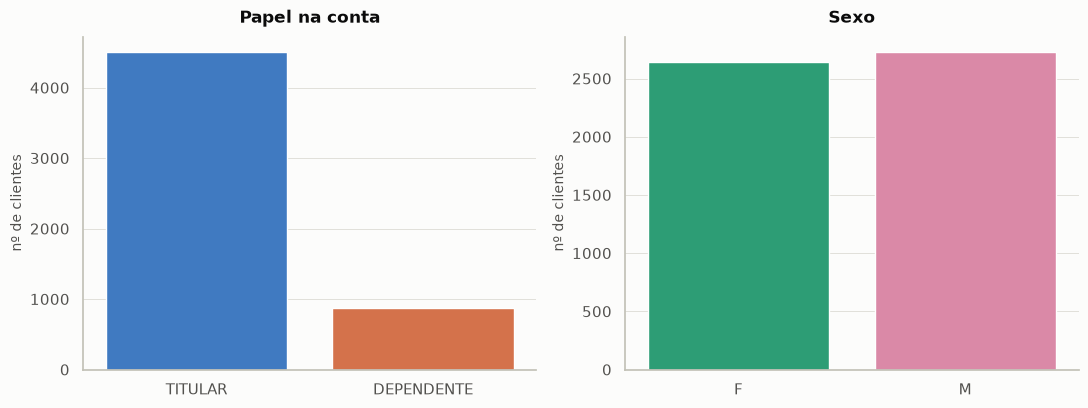

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

sns.countplot(data=client, x="relationship_type", hue="relationship_type",
              palette=[BLUE, ORANGE], legend=False, ax=axes[0])
finish(axes[0], "Papel na conta", "", "nº de clientes")

sns.countplot(data=client, x="gender", hue="gender",
              palette=[AQUA, MAGENTA], legend=False, ax=axes[1])
finish(axes[1], "Sexo", "", "nº de clientes")

plt.tight_layout()
plt.show()


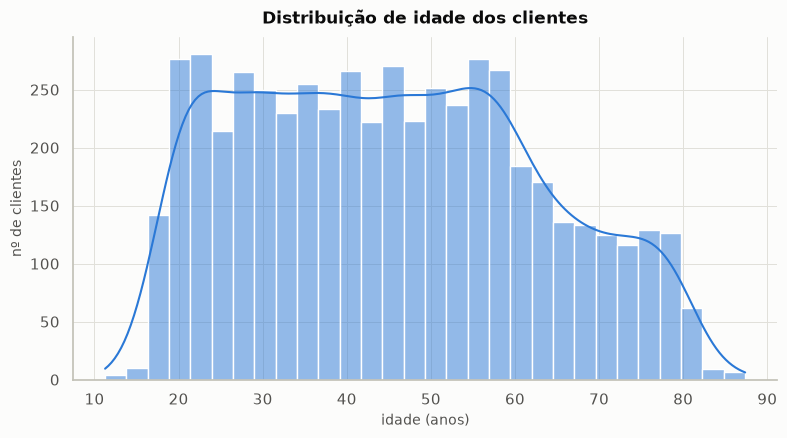

In [20]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(age_years, bins=30, color=BLUE, kde=True, ax=ax)
finish(ax, "Distribuição de idade dos clientes", "idade (anos)", "nº de clientes")
plt.tight_layout()
plt.show()


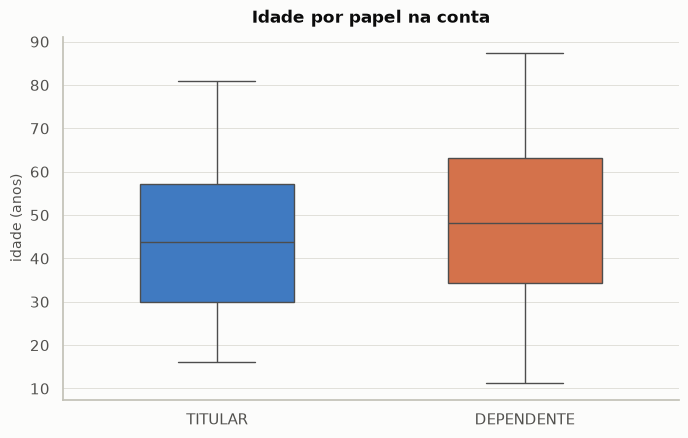

In [21]:
plot_df = client.assign(idade=age_years)

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.boxplot(
    data=plot_df, x="relationship_type", y="idade", hue="relationship_type",
    palette=[BLUE, ORANGE], legend=False, width=0.5, fliersize=3, ax=ax,
)
finish(ax, "Idade por papel na conta", "", "idade (anos)")
plt.tight_layout()
plt.show()


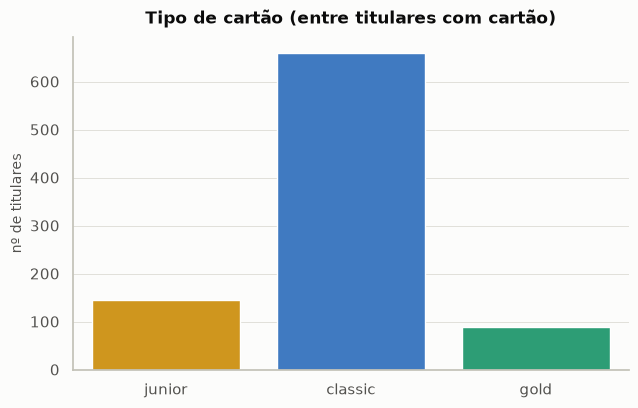

In [22]:
fig, ax = plt.subplots(figsize=(6.5, 4.2))
sns.countplot(
    data=titular.dropna(subset=["card_type"]), x="card_type",
    order=["junior", "classic", "gold"], hue="card_type",
    palette=[AQUA, BLUE, YELLOW], legend=False, ax=ax,
)
finish(ax, "Tipo de cartão (entre titulares com cartão)", "", "nº de titulares")
plt.tight_layout()
plt.show()


## 2.6 Insights para a Gold

Visão Geral:\
A relações entre cliente, conta e cartão serão fundamentais na hora de agrupar as movimentações de cada indivíduo.\
Apenas ~20% dos clientes possuem um cartão, essa baixa taxa de posse concentrada no tipo `classic` não deve ser uma feature valiosa.\
Contudo, pode set útil se somada a outras informações, ex. cartão + salário + distrito.\
Atenção para:
- `has_dependente`: A regra é simples um titular sempre, N dependentes é opcional.


# 3. `account`

## 3.1 Dicionário de dados

Esta tabela contém informações de `account` (contas) e `loan` (empréstimos).\
Mantendo a relação de uma conta por cliente e um empréstimo por conta.

| Coluna | Descrição |
|---|---|
| `account_id` (PK) | Chave de identificação da conta |
| `district_id` (FK -> `district`) | Distrito da conta |
| `frequency` | Frequência de emissão do extrato: `MENSAL`, `SEMANAL`, `POR TRANSACAO` |
| `date` | Data de criação da conta |
| `loan_id` | Chave do empréstimo (nulo para contas sem empréstimo) |
| `loan_date` | Data de concessão do empréstimo (nulo se sem empréstimo) |
| `loan_amount` | Valor do empréstimo (nulo se sem empréstimo) |
| `loan_duration` | Duração do empréstimo em meses (nulo se sem empréstimo) |
| `loan_payments` | Valor do pagamento mensal (nulo se sem empréstimo) |
| `loan_status` | Situação do empréstimo: `ENCERRADO ADIMPLENTE`, `ENCERRADO INADIMPLENTE`, `ATIVO ADIMPLENTE`, `ATIVO INADIMPLENTE` (nulo se sem empréstimo) |


## 3.2 Volume, tipo e formato

In [23]:
account = silver["account"]
print(f"shape: {account.shape}")
account.dtypes


shape: (4500, 10)


account_id       string[python]
district_id      string[python]
frequency        string[python]
date             datetime64[ns]
loan_id          string[python]
loan_date        datetime64[ns]
loan_amount               Int64
loan_duration             Int64
loan_payments           float64
loan_status      string[python]
dtype: object

## 3.3 Indicadores e chaves primárias

In [24]:
print("account_id é PK (única e sem nulos)?", account['account_id'].is_unique and account['account_id'].notna().all())
print("district_id -> district.district_id (FK íntegra)?", account['district_id'].isin(silver['district']['district_id']).all())

has_loan = account["loan_id"].notna()
print(f"\ntaxa de contas com empréstimo: {has_loan.mean():.2%} ({has_loan.sum()} de {len(account)})")
print(f"intervalo de abertura de conta: {account['date'].min().date()} a {account['date'].max().date()}")


account_id é PK (única e sem nulos)? True
district_id -> district.district_id (FK íntegra)? True

taxa de contas com empréstimo: 15.16% (682 de 4500)
intervalo de abertura de conta: 1993-01-01 a 1997-12-29


## 3.4 Nulos, duplicatas e valores fora do padrão

In [25]:
quality_overview(account)


,dtype,n_nulos,pct_nulos,n_unicos,pct_unicos
account_id,string,0,0.00,4500,100.00
district_id,string,0,0.00,77,1.71
frequency,string,0,0.00,3,0.07
date,datetime64[ns],0,0.00,1535,34.11
loan_id,string,3818,84.84,682,15.16
loan_date,datetime64[ns],3818,84.84,559,12.42
loan_amount,Int64,3818,84.84,645,14.33
loan_duration,Int64,3818,84.84,5,0.11
loan_payments,float64,3818,84.84,577,12.82
loan_status,string,3818,84.84,4,0.09


In [26]:
duplicate_report(account, subset=["account_id"])
print("\n(nulos em loan_* são estruturais: só as contas com empréstimo têm esses valores)")


Linhas 100% duplicadas: 0
Linhas duplicadas em ['account_id']: 0

(nulos em loan_* são estruturais: só as contas com empréstimo têm esses valores)


In [27]:
loan = account[has_loan]
outlier_iqr(loan, ["loan_amount", "loan_duration", "loan_payments"])


,limite_inferior,limite_superior,n_outliers,pct_outliers
coluna,,,,
loan_amount,-149151.00,426537.00,18,2.64
loan_duration,-12.00,84.00,0,0.00
loan_payments,-2527.75,10818.25,0,0.00


## 3.5 Gráficos

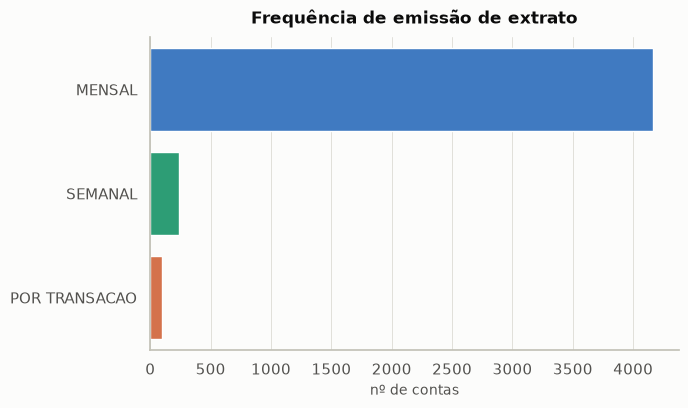

In [28]:
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.countplot(
    data=account, y="frequency",
    order=account["frequency"].value_counts().index,
    hue="frequency", palette=CATEGORICAL[: account["frequency"].nunique()], legend=False, ax=ax,
)
finish(ax, "Frequência de emissão de extrato", "nº de contas", "")
plt.tight_layout()
plt.show()


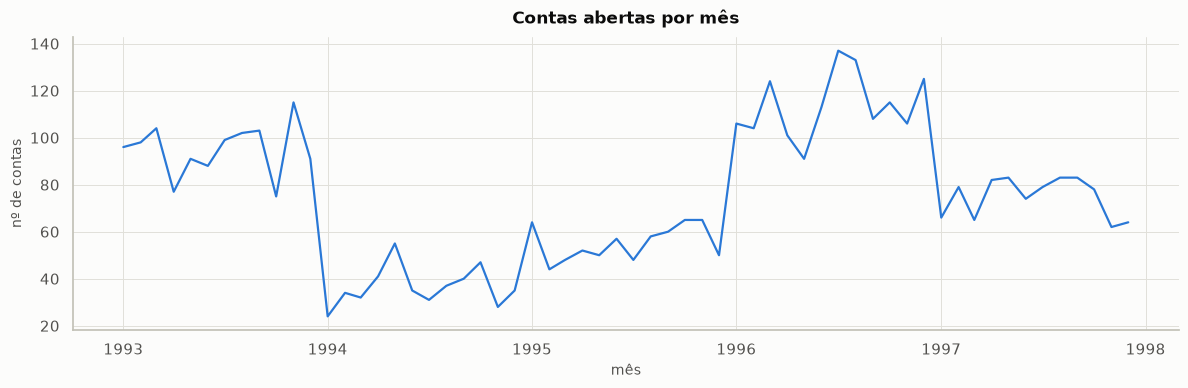

In [29]:
acc_month = account["date"].dt.to_period("M").dt.to_timestamp().value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
sns.lineplot(x=acc_month.index, y=acc_month.values, color=BLUE, linewidth=1.6, ax=ax)
finish(ax, "Contas abertas por mês", "mês", "nº de contas")
plt.tight_layout()
plt.show()


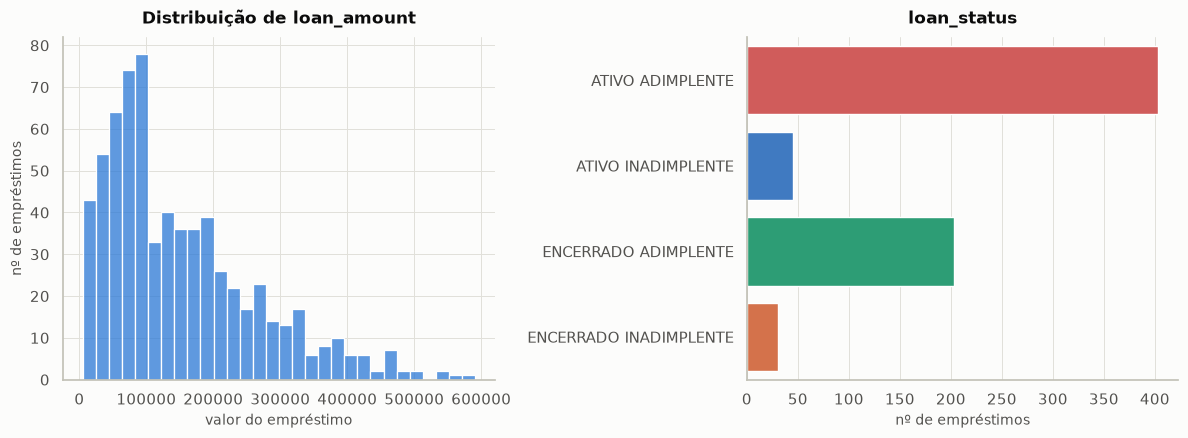

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(loan["loan_amount"], bins=30, color=BLUE, ax=axes[0])
finish(axes[0], "Distribuição de loan_amount", "valor do empréstimo", "nº de empréstimos")

status_order = ["ATIVO ADIMPLENTE", "ATIVO INADIMPLENTE", "ENCERRADO ADIMPLENTE", "ENCERRADO INADIMPLENTE"]
sns.countplot(data=loan, y="loan_status", order=status_order,
              hue="loan_status", palette=[AQUA, ORANGE, BLUE, RED], legend=False, ax=axes[1])
finish(axes[1], "loan_status", "nº de empréstimos", "")

plt.tight_layout()
plt.show()


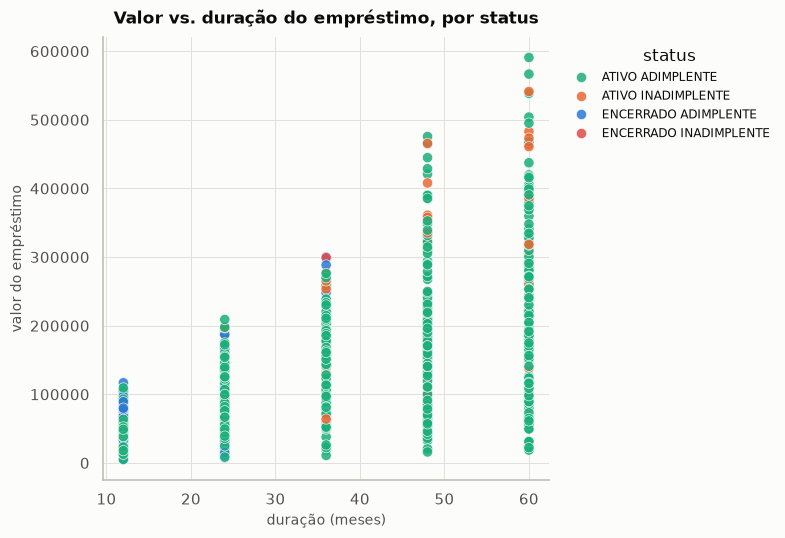

In [31]:
# cores por semântica: adimplente em tons frios, inadimplente em tons quentes
status_palette = {
    "ATIVO ADIMPLENTE": AQUA, "ENCERRADO ADIMPLENTE": BLUE,
    "ATIVO INADIMPLENTE": ORANGE, "ENCERRADO INADIMPLENTE": RED,
}

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.scatterplot(
    data=loan, x="loan_duration", y="loan_amount", hue="loan_status",
    hue_order=status_order, palette=status_palette,
    s=55, edgecolor="white", linewidth=0.5, alpha=0.85, ax=ax,
)
finish(ax, "Valor vs. duração do empréstimo, por status", "duração (meses)", "valor do empréstimo")
ax.legend(title="status", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()


## 3.6 Insights para a Gold

Visão Geral:\
Tabela com informações chaves para compisção de features na camada gold.\
Atenção para:
- `loan_status`/`loan_amount`/`loan_duration` representam um possível vazamento de dados. 
- `loan_ativo_no_mes` e `account_age_months`

# 4. `order`

## 4.1 Dicionário de dados

Esta tabela contém as ordens de pagamento realizadas por cada conta emissora.
Nota: As ordens de pagamentos não possuem sem data associada, visto que são ordens recorrentes.

| Coluna | Descrição |
|---|---|
| `order_id` (PK) | Chave de identificação da ordem |
| `account_id` (FK -> `account`) | Conta emissora |
| `bank_to` | Código do banco destinatário (2 letras) |
| `account_to` | Conta destinatária |
| `amount` | Valor debitado da conta |
| `k_symbol` | Propósito do pagamento: `SEGURO`, `CONTAS DOMESTICAS`, `ARRENDAMENTO`, `PAGAMENTO DE EMPRESTIMO` ou `DESCONHECIDO` (nulo estrutural) |



## 4.2 Volume, tipo e formato

In [32]:
order = silver["order"]
print(f"shape: {order.shape}")
order.dtypes


shape: (6471, 6)


order_id      string[python]
account_id    string[python]
bank_to       string[python]
account_to    string[python]
amount               float64
k_symbol      string[python]
dtype: object

## 4.3 Indicadores e chaves primárias

In [33]:
print("order_id é PK (única e sem nulos)?", order['order_id'].is_unique and order['order_id'].notna().all())
print("account_id -> account.account_id (FK íntegra)?", order['account_id'].isin(account['account_id']).all())

orders_per_acc = order.groupby("account_id").size().reindex(account["account_id"], fill_value=0)
print(f"\norders por conta — média: {orders_per_acc.mean():.2f} | % contas sem nenhuma order: {(orders_per_acc == 0).mean():.1%}")
print(f"bancos distintos (bank_to): {order['bank_to'].nunique()}")


order_id é PK (única e sem nulos)? True
account_id -> account.account_id (FK íntegra)? True

orders por conta — média: 1.44 | % contas sem nenhuma order: 16.5%
bancos distintos (bank_to): 13


## 4.4 Nulos, duplicatas e valores fora do padrão

In [34]:
quality_overview(order)


,dtype,n_nulos,pct_nulos,n_unicos,pct_unicos
order_id,string,0,0.0,6471,100.00
account_id,string,0,0.0,3758,58.07
bank_to,string,0,0.0,13,0.20
account_to,string,0,0.0,6446,99.61
amount,float64,0,0.0,4412,68.18
k_symbol,string,0,0.0,5,0.08


In [35]:
duplicate_report(order, subset=["order_id"])


Linhas 100% duplicadas: 0
Linhas duplicadas em ['order_id']: 0


In [36]:
outlier_iqr(order, ["amount"])


,limite_inferior,limite_superior,n_outliers,pct_outliers
coluna,,,,
amount,-3816.5,9671.5,175,2.7


In [37]:
desconhecido_rate(order, ["k_symbol"])


,n_desconhecido,pct_desconhecido
coluna,,
k_symbol,1379,21.31


## 4.5 Gráficos

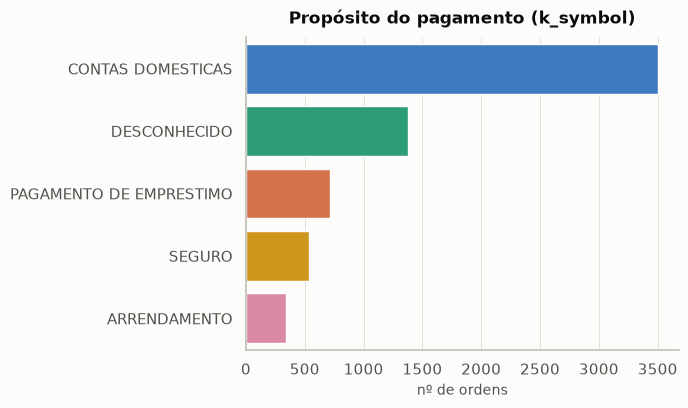

In [38]:
fig, ax = plt.subplots(figsize=(7, 4.2))
sns.countplot(
    data=order, y="k_symbol", order=order["k_symbol"].value_counts().index,
    hue="k_symbol", palette=CATEGORICAL[: order["k_symbol"].nunique()], legend=False, ax=ax,
)
finish(ax, "Propósito do pagamento (k_symbol)", "nº de ordens", "")
plt.tight_layout()
plt.show()


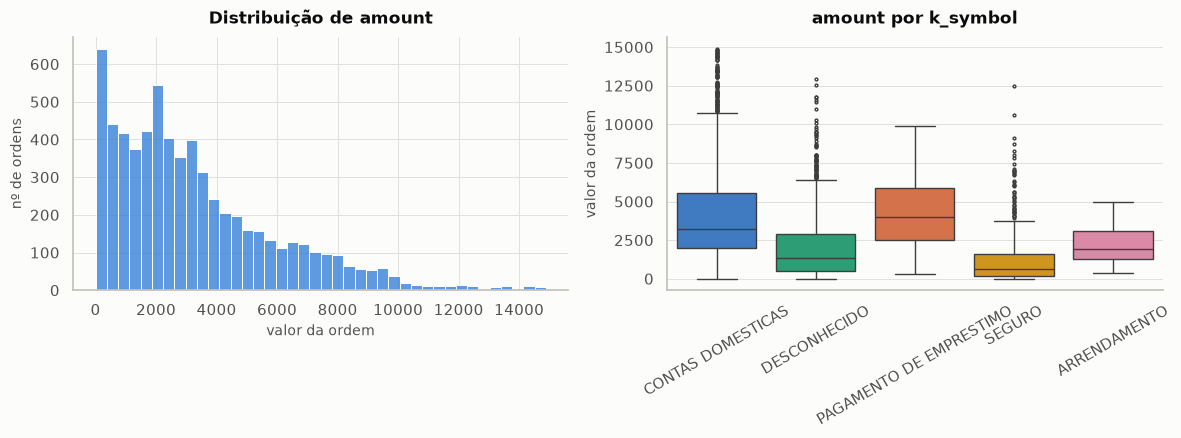

In [39]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(order["amount"], bins=40, color=BLUE, ax=axes[0])
finish(axes[0], "Distribuição de amount", "valor da ordem", "nº de ordens")

sns.boxplot(
    data=order, x="k_symbol", y="amount", hue="k_symbol",
    order=order["k_symbol"].value_counts().index, palette=CATEGORICAL[: order["k_symbol"].nunique()],
    legend=False, fliersize=2, ax=axes[1],
)
finish(axes[1], "amount por k_symbol", "", "valor da ordem")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()


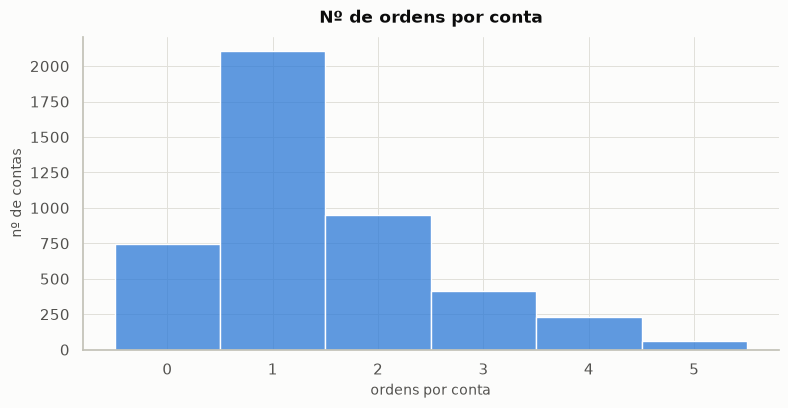

In [40]:
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.histplot(orders_per_acc, bins=range(0, 7), color=BLUE, discrete=True, ax=ax)
finish(ax, "Nº de ordens por conta", "ordens por conta", "nº de contas")
plt.tight_layout()
plt.show()


## 4.6 Insights para a Gold

Visão Geral:\
Aproximadamente 16% das contas não possuem ordens de pagamentos, além disso a tabela apresenta uma grande quantidade de ordens com ammount igual a zero.\
Atenção para:
- `k_symbol`: As categorias não estão balancedas e possuem escalas de valores distintas (ex.: `PAGAMENTO DE EMPRESTIMO` tende a valores maiores que `SEGURO`).


# 5. `trans`

## 5.1 Dicionário de dados

Esta tabela reune as transações realizadas pelos clientes, cada linha representa uma transação realizada por uma conta.

| Coluna | Descrição |
|---|---|
| `trans_id` (PK) | Chave de identificação da transação |
| `account_id` (FK -> `account`) | Conta da transação |
| `date` | Data da transação |
| `type` | Tipo: `CREDITO`, `DEBITO`, `SAQUE` (variação legada de débito) |
| `operation` | Modo: `SAQUE EM ESPECIE`, `DEPOSITO EM ESPECIE`, `TRANSFERENCIA RECEBIDA`, `TRANSFERENCIA ENVIADA`, `SAQUE NO CARTAO` (ou `DESCONHECIDO`) |
| `amount` | Valor da transação |
| `balance` | Saldo da conta após a transação |
| `k_symbol` | Caracterização: `SEGURO`, `TARIFA DE SERVICO`, `JUROS CREDITADOS`, `JUROS PUNITIVOS`, `CONTAS DOMESTICAS`, `APOSENTADORIA`, `PAGAMENTO DE EMPRESTIMO` (ou `DESCONHECIDO`) |
| `bank` | Banco parceiro (só em transferências, senão `DESCONHECIDO`) |
| `account` | Conta parceira (só em transferências, senão `DESCONHECIDO`) |



## 5.2 Volume, tipo e formato

In [41]:
trans = silver["trans"]
print(f"shape: {trans.shape}")
print(f"memória: {trans.memory_usage(deep=True).sum() / 1e6:.1f} MB")
trans.dtypes


shape: (1056320, 10)


memória: 459.3 MB


trans_id      string[python]
account_id    string[python]
date          datetime64[ns]
type          string[python]
operation     string[python]
amount               float64
balance              float64
k_symbol      string[python]
bank          string[python]
account       string[python]
dtype: object

## 5.3 Indicadores e chaves primárias

In [42]:
print("trans_id é PK (única e sem nulos)?", trans['trans_id'].is_unique and trans['trans_id'].notna().all())
print("account_id -> account.account_id (FK íntegra)?", trans['account_id'].isin(account['account_id']).all())

trans_per_acc = trans.groupby("account_id").size().reindex(account["account_id"], fill_value=0)
print(f"\nintervalo de datas: {trans['date'].min().date()} a {trans['date'].max().date()}")
print(f"transações por conta — média: {trans_per_acc.mean():.1f} | min: {trans_per_acc.min()} | max: {trans_per_acc.max()}")
print(f"\ndistribuição de type:\n{(trans['type'].value_counts(normalize=True) * 100).round(1)}")


trans_id é PK (única e sem nulos)? True
account_id -> account.account_id (FK íntegra)? True

intervalo de datas: 1993-01-01 a 1998-12-31
transações por conta — média: 234.7 | min: 9 | max: 675



distribuição de type:
type
DEBITO     60.1
CREDITO    38.3
SAQUE       1.6
Name: proportion, dtype: Float64


## 5.4 Nulos, duplicatas e valores fora do padrão

In [43]:
quality_overview(trans)


,dtype,n_nulos,pct_nulos,n_unicos,pct_unicos
trans_id,string,0,0.0,1056320,100.00
account_id,string,0,0.0,4500,0.43
date,datetime64[ns],0,0.0,2191,0.21
type,string,0,0.0,3,0.00
operation,string,0,0.0,6,0.00
amount,float64,0,0.0,40400,3.82
balance,float64,0,0.0,542739,51.38
k_symbol,string,0,0.0,8,0.00
bank,string,0,0.0,14,0.00
account,string,0,0.0,7666,0.73


In [44]:
duplicate_report(trans, subset=["trans_id"])


Linhas 100% duplicadas: 0
Linhas duplicadas em ['trans_id']: 0


In [45]:
outlier_iqr(trans, ["amount", "balance"])


,limite_inferior,limite_superior,n_outliers,pct_outliers
coluna,,,,
amount,-9860.25,16796.15,120215,11.38
balance,-18399.19,90405.31,34806,3.30


In [46]:
desconhecido_rate(trans, ["operation", "k_symbol", "bank", "account"])


,n_desconhecido,pct_desconhecido
coluna,,
operation,183114,17.34
k_symbol,535314,50.68
bank,782812,74.11
account,760931,72.04


## 5.5 Gráficos

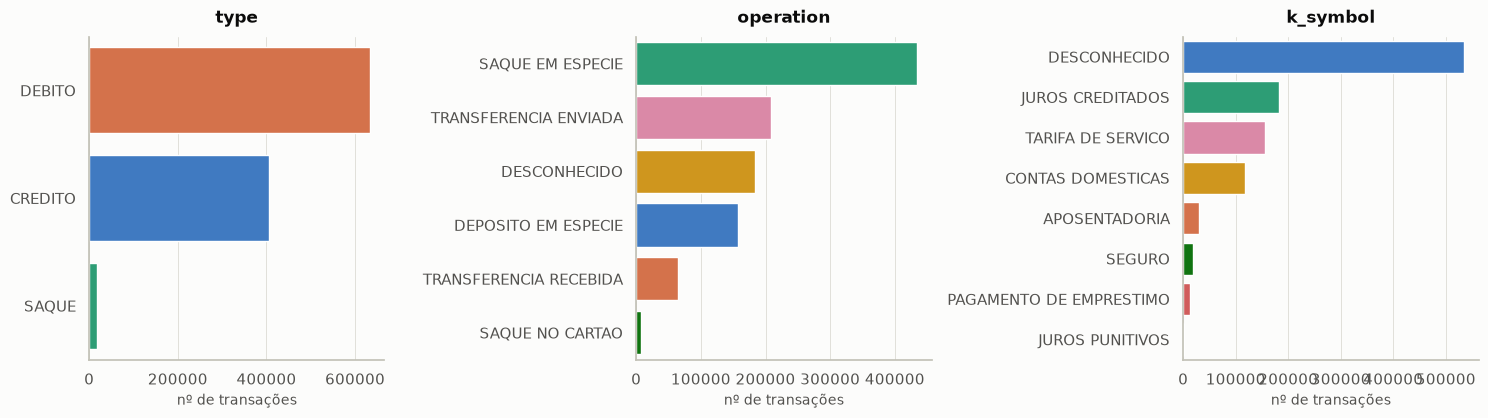

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, col in zip(axes, ["type", "operation", "k_symbol"]):
    order_vals = trans[col].value_counts().index
    sns.countplot(data=trans, y=col, order=order_vals, hue=col,
                  palette=CATEGORICAL[: trans[col].nunique()], legend=False, ax=ax)
    finish(ax, col, "nº de transações", "")
plt.tight_layout()
plt.show()


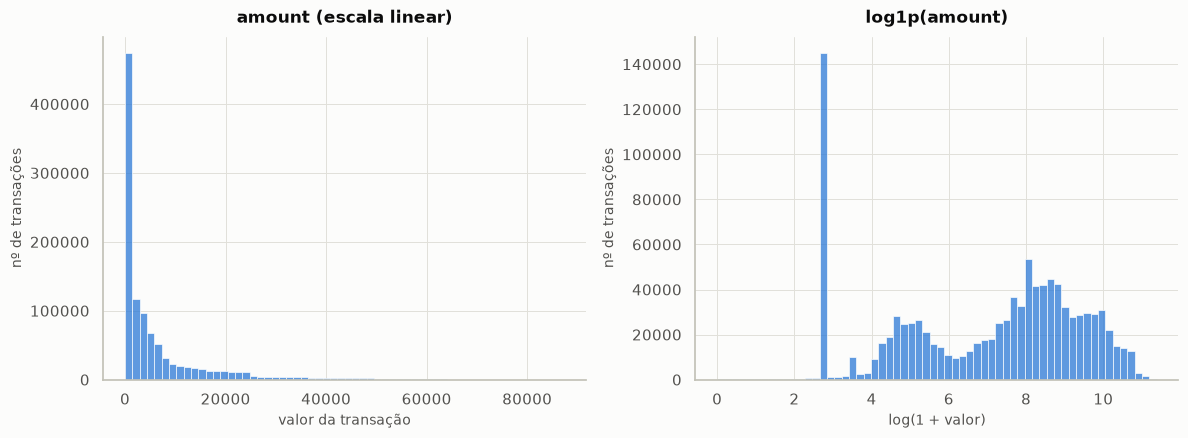

In [48]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(trans["amount"], bins=60, color=BLUE, ax=axes[0])
finish(axes[0], "amount (escala linear)", "valor da transação", "nº de transações")

sns.histplot(np.log1p(trans["amount"]), bins=60, color=BLUE, ax=axes[1])
finish(axes[1], "log1p(amount)", "log(1 + valor)", "nº de transações")

plt.tight_layout()
plt.show()


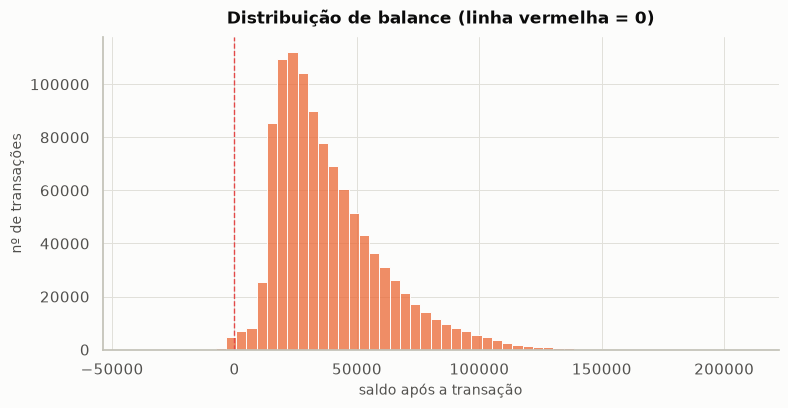

In [49]:
fig, ax = plt.subplots(figsize=(8, 4.2))
sns.histplot(trans["balance"], bins=60, color=ORANGE, ax=ax)
ax.axvline(0, color=RED, linewidth=1, linestyle="--")
finish(ax, "Distribuição de balance (linha vermelha = 0)", "saldo após a transação", "nº de transações")
plt.tight_layout()
plt.show()


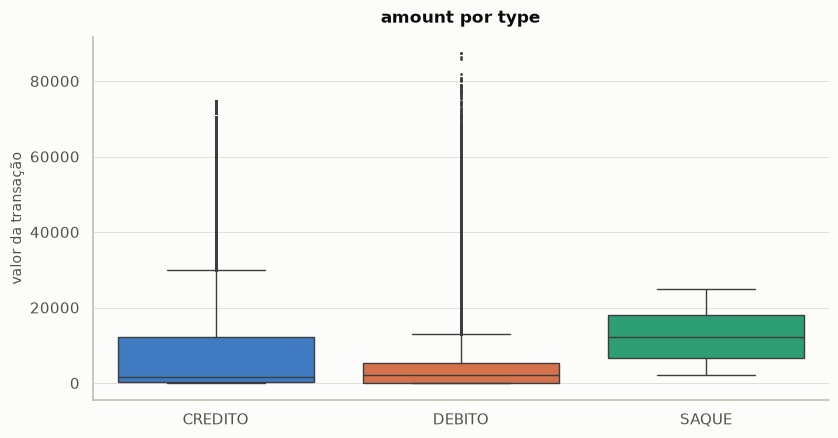

In [50]:
fig, ax = plt.subplots(figsize=(8.5, 4.5))
sns.boxplot(
    data=trans, x="type", y="amount", hue="type",
    order=["CREDITO", "DEBITO", "SAQUE"], palette=[BLUE, ORANGE, AQUA],
    legend=False, fliersize=1, ax=ax,
)
finish(ax, "amount por type", "", "valor da transação")
plt.tight_layout()
plt.show()


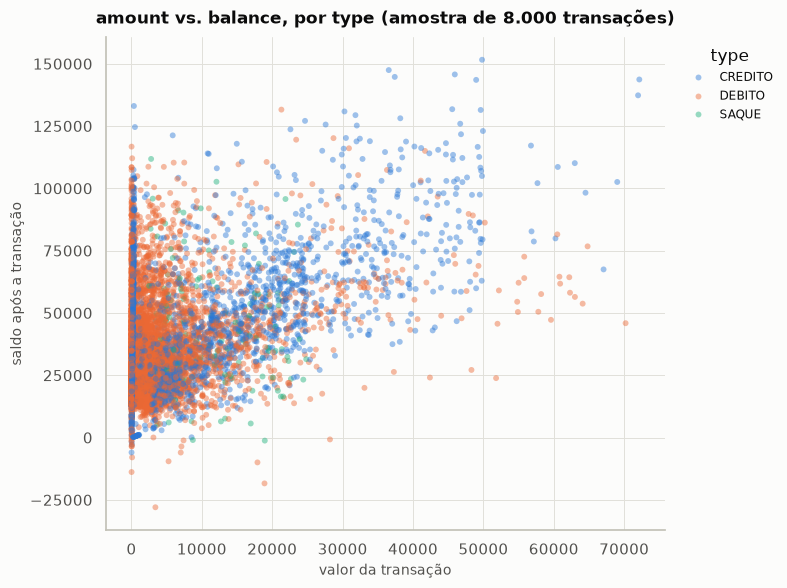

In [51]:
# amostra para o scatter (1M+ pontos não renderiza de forma legível/performática)
sample = trans.sample(n=8000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(
    data=sample, x="amount", y="balance", hue="type",
    hue_order=["CREDITO", "DEBITO", "SAQUE"], palette=[BLUE, ORANGE, AQUA],
    s=18, alpha=0.45, linewidth=0, ax=ax,
)
finish(ax, "amount vs. balance, por type (amostra de 8.000 transações)", "valor da transação", "saldo após a transação")
ax.legend(title="type", bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False, fontsize=8.5)
plt.tight_layout()
plt.show()


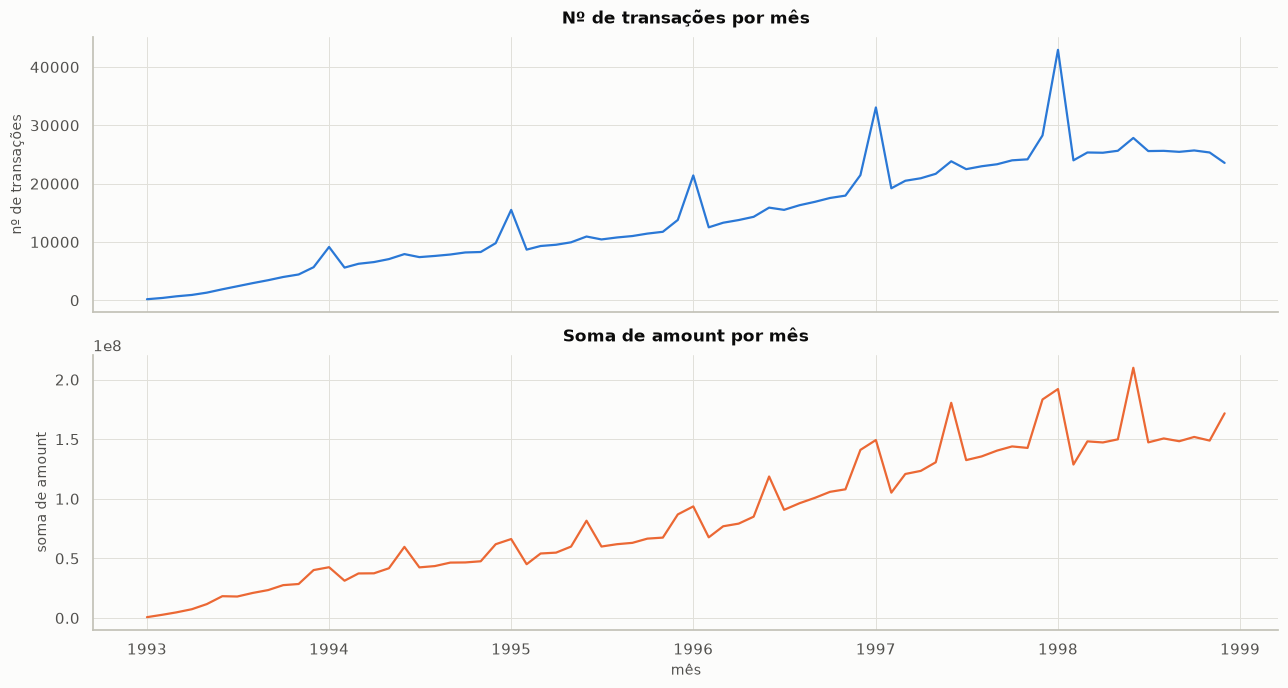

In [52]:
monthly = trans.groupby(trans["date"].dt.to_period("M"))["amount"].agg(
    n_transacoes="count", soma_amount="sum",
).reset_index()
monthly["date"] = monthly["date"].dt.to_timestamp()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

sns.lineplot(data=monthly, x="date", y="n_transacoes", color=BLUE, linewidth=1.6, ax=axes[0])
finish(axes[0], "Nº de transações por mês", "", "nº de transações")

sns.lineplot(data=monthly, x="date", y="soma_amount", color=ORANGE, linewidth=1.6, ax=axes[1])
finish(axes[1], "Soma de amount por mês", "mês", "soma de amount")

plt.tight_layout()
plt.show()


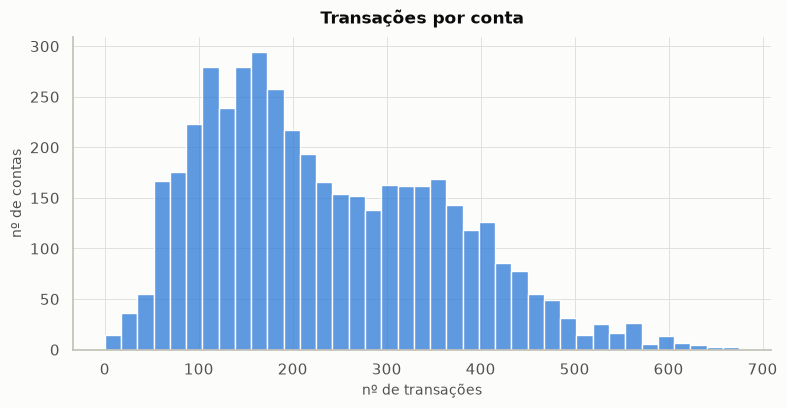

In [53]:
fig, ax = plt.subplots(figsize=(8, 4.2))
bins = np.linspace(0, trans_per_acc.max(), 40)
sns.histplot(trans_per_acc, bins=bins, color=BLUE, ax=ax)
finish(ax, "Transações por conta", "nº de transações", "nº de contas")
plt.tight_layout()
plt.show()


## 5.6 Insights para a Gold

Visão Geral:\
Uma das principais tabelas do cojunto, a distribuição de `amount` é fortemente assimétrica à direita.\
Necessário aplicar uma transformação logaritmica para coluna.\
Atenção para:
- `balance` raramente fica negativo, a maior parte dos registros está fica acima de 0, ou seja, poucas contas operam no vermelho; 
